In [1]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42  # to edit text in Illustrator
import pandas as pd


%load_ext autoreload
%autoreload 2
from seismosocialdistancing_simple import SeismoNoise
import seismosocialdistancing


In [2]:
NETWORK = "XG"
STATION = "BB01"
LOCATION = ""
CHANNEL = "HHZ"
dataset = "Skience2026"
time_zone = "Europe/Zurich"
sitedesc = "on ice"
logo = 'None'


## 10. Reload a saved PPSD from disk

Previously computed PPSDs can be reloaded from `.npz` files using
`PPSD.load_npz()`. This is much faster than recomputing from raw waveforms —
especially useful when you've accumulated weeks or months of data.

In [3]:
from obspy.signal.spectral_estimation import PPSD

ppsd = PPSD.load_npz(f"./{NETWORK}.{STATION}.{LOCATION}.{CHANNEL}.npz")

print(f"Loaded PPSD — {len(ppsd.current_times_used)} segment(s)")
print(f"  Station : {ppsd.id}")
print(f"  Period  : {ppsd.period_bin_centers[0]:.3f} – {ppsd.period_bin_centers[-1]:.1f} s")
print(f"  Time    : {ppsd.current_times_used[0].date} → {ppsd.current_times_used[-1].date}")

Loaded PPSD — 141 segment(s)
  Station : XG.BB01..HHZ
  Period  : 0.010 – 655.4 s
  Time    : 2024-03-20 → 2024-03-22


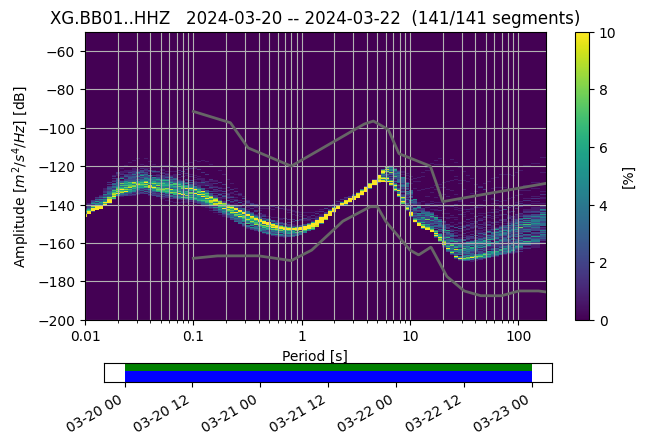

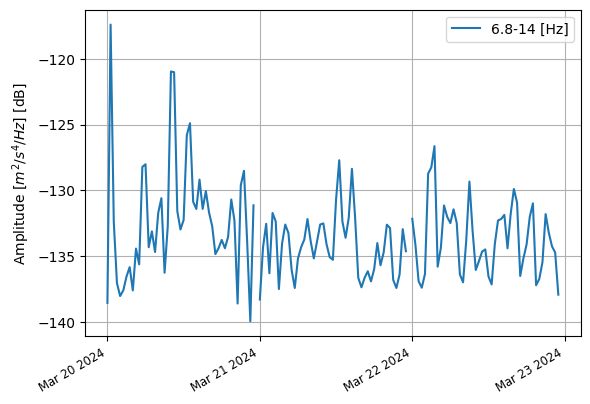

/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/.venv/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/.venv/lib/python3.12/site-packages/obspy/signal/spectral_estimation.py:1709: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  fig.tight_layout()
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/.venv/lib/python3.12/site-packages/obspy/signal/spectral_estimation.py:

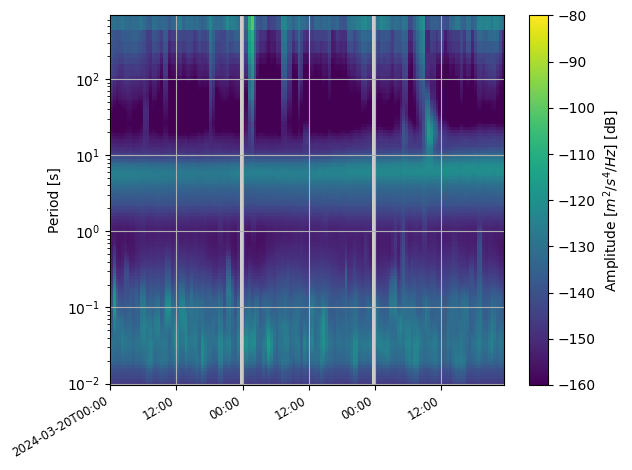

In [4]:
# Let's check we got the right stuff
target_period = 0.1

ppsd.plot(max_percentage=10)
ppsd.plot_temporal(target_period)
ppsd.plot_spectrogram(clim=(-160,-80))

In [5]:
freqs = [(0.1,1.0),(1.0,20.0),(4.0,14.0),(4.0,20.0),(2.0,100.0)]
ind_times = pd.DatetimeIndex([d.datetime for d in ppsd.current_times_used])
data = pd.DataFrame(ppsd.psd_values, index=ind_times, columns=1./ppsd.period_bin_centers)
data = data.sort_index(axis=1)
displacement_RMS = {}
displacement_RMS[f"{NETWORK}.{STATION}.{LOCATION}.{CHANNEL}"] = seismosocialdistancing.df_rms(data, freqs, output="DISP")

In [6]:
displacement_RMS[f"{NETWORK}.{STATION}.{LOCATION}.{CHANNEL}"].head()

,0.1-1.0,1.0-20.0,4.0-14.0,4.0-20.0,2.0-100.0
2024-03-20 00:00:00,1.257449e-07,3.042197e-10,1.245537e-10,1.279258e-10,1.803966e-10
2024-03-20 00:30:00,1.212184e-07,1.445212e-09,1.335261e-09,1.342749e-09,1.413000e-09
2024-03-20 01:00:00,1.213860e-07,3.427625e-10,2.159811e-10,2.283802e-10,2.589740e-10
2024-03-20 01:30:00,1.252137e-07,2.790146e-10,1.291144e-10,1.452734e-10,1.851342e-10
2024-03-20 02:00:00,1.230426e-07,2.972598e-10,1.236899e-10,1.380637e-10,1.932500e-10


In [7]:
args = {'band':"4.0-14.0",       # might be None or commented ("4.0-14.0" per default) or any of the tupples in freqs
        'time_zone':time_zone,   # required for clockplots
        'sitedesc':sitedesc,     # might be None or commented
        'logo':logo,             # might be None or commented
        'unit':'nm',
        'resample': ("30", "min")
        }

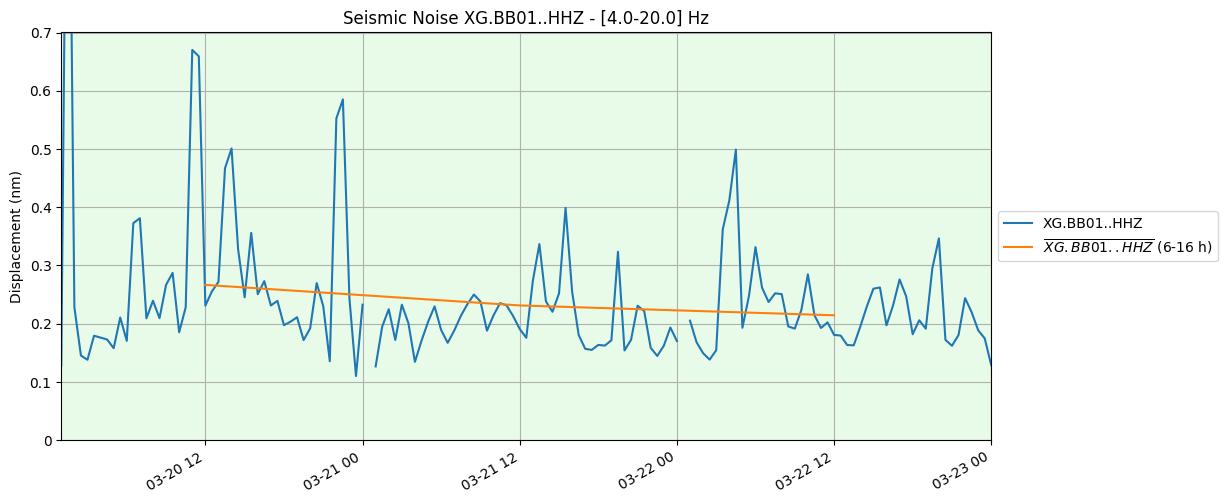

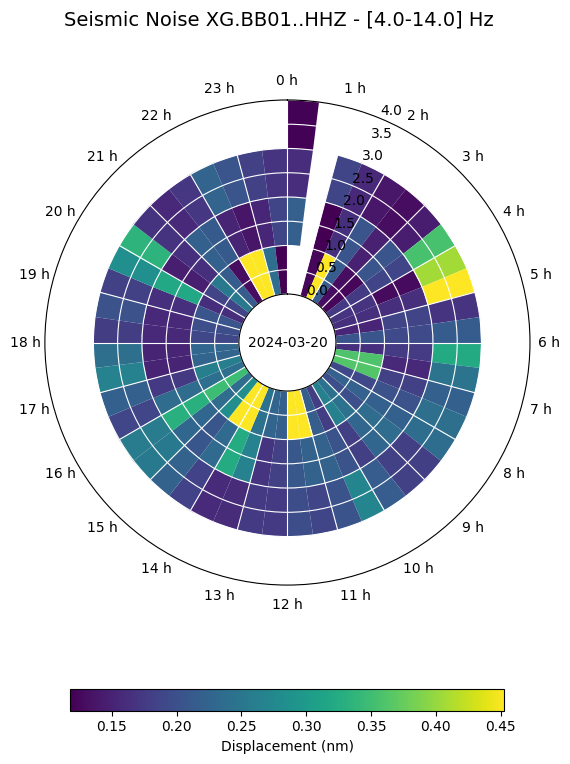

In [8]:
sn = SeismoNoise(displacement_RMS)
sn.plot(band="4.0-20.0")                          # timeseries
sn.plot(type="clockmaps")


/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/02 Noise - HVSR - CCF/seismosocialdistancing_simple.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["%.2g %s" % (i, unit) for i in ax.get_yticks()], fontsize=7)


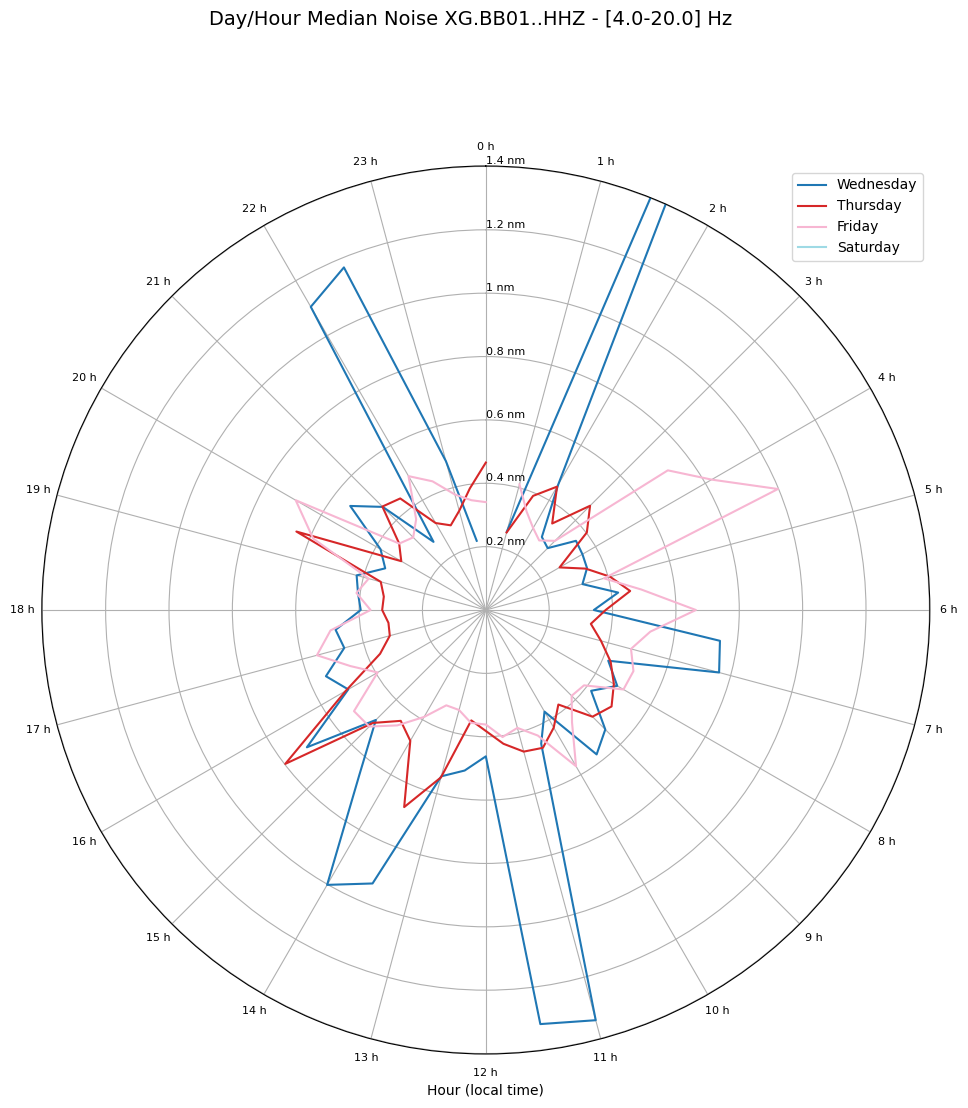

In [9]:
sn.plot(type="clockplots", band="4.0-20.0")

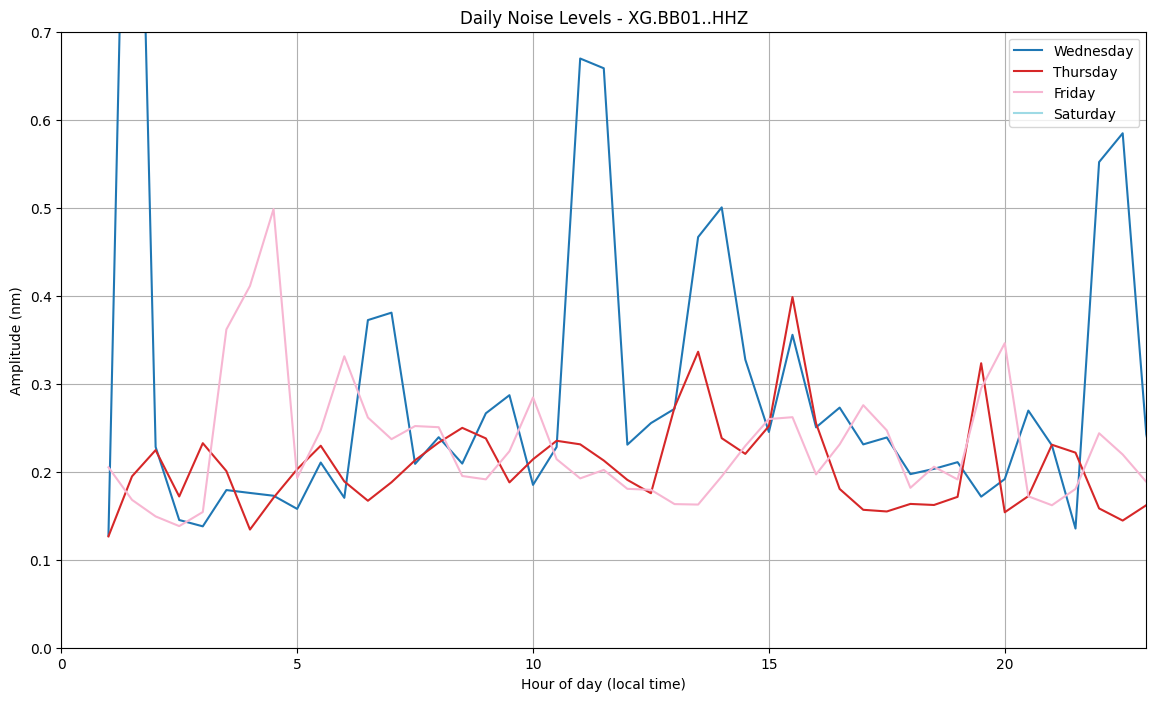

In [10]:
sn.plot(type="dailyplots", band="4.0-20.0")